# 17 — Pathology prevalence among locked first visits

Cross-references `diagnostic_notes_history` flags (already computed by the app's pattern-flagging system) for clients whose first visit is locked. Mirrors `docs/clientQueries.md` §3.4.

In [1]:
import pandas as pd
from db import get_engine

engine = get_engine()

In [2]:
query = """
SELECT
  ROUND(100 * AVG(has_diabetes), 1)              AS pct_diabetes,
  ROUND(100 * AVG(has_renal_failure), 1)          AS pct_renal_failure,
  ROUND(100 * AVG(has_liver_dysfunction), 1)      AS pct_liver_dysfunction,
  ROUND(100 * AVG(has_metabolic_syndrome), 1)     AS pct_metabolic_syndrome,
  ROUND(100 * AVG(has_insulin_resistance), 1)     AS pct_insulin_resistance,
  ROUND(100 * AVG(has_cardiovascular_issues), 1)  AS pct_cardiovascular_issues,
  ROUND(100 * AVG(requires_specialist), 1)        AS pct_requires_specialist,
  COUNT(*) AS locked_first_visits_analyzed
FROM diagnostic_notes_history dnh
JOIN visits v ON v.visit_id = dnh.visit_id
WHERE v.visit_type = '1' AND v.visit_is_locked = 1;
"""

df = pd.read_sql(query, engine)
print(df)

   pct_diabetes  pct_renal_failure  pct_liver_dysfunction  \
0          12.8                0.0                    0.0   

   pct_metabolic_syndrome  pct_insulin_resistance  pct_cardiovascular_issues  \
0                     5.1                     7.7                       28.2   

   pct_requires_specialist  locked_first_visits_analyzed  
0                     76.9                            39  


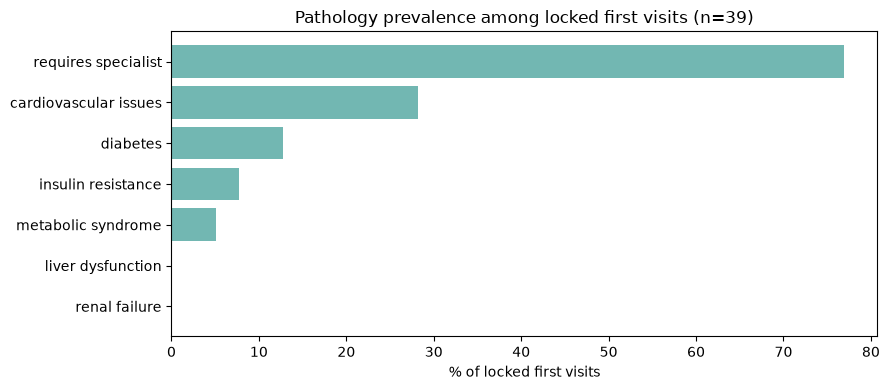

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

prevalence = (
    df.drop(columns="locked_first_visits_analyzed")
    .melt(var_name="pathology", value_name="pct_prevalence")
    .assign(pathology=lambda d: d["pathology"].str.removeprefix("pct_").str.replace("_", " "))
    .sort_values("pct_prevalence")
)

n = df["locked_first_visits_analyzed"].iloc[0]

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(prevalence))))
ax.barh(prevalence["pathology"], prevalence["pct_prevalence"], color="#72B7B2")
ax.set_xlabel("% of locked first visits")
ax.set_title(f"Pathology prevalence among locked first visits (n={n})")
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/pathology_prevalence.png", dpi=150)
plt.show()